# ASH Backtest Diagnostics

Objective:
- Diagnose backtest 2 using the backtest JSON and the sibling submission config that actually produced it.
- Compare backtest 2 against backtest 1 to evaluate the `dislocation_threshold` change from `5.0` to `3.0`.
- End with exactly one main next strategy change and the exact metrics to compare on the next run.


In [1]:
from pathlib import Path

JSON_PATH = Path("imc backtest results/attempt 2/187756.json")
BASELINE_JSON_PATH = Path("imc backtest results/attempt 1/173180.json")
CURRENT_RUN_LABEL = JSON_PATH.parent.name
BASELINE_RUN_LABEL = BASELINE_JSON_PATH.parent.name
TARGET_PRODUCT = "ASH_COATED_OSMIUM"
ANCHOR_LOOKBACK = 30
THIN_DEPTH_THRESHOLD = 8
VOLATILITY_ROLLING_WINDOW = 5
HIGH_VOL_QUANTILE = 0.80
LOW_VOL_QUANTILE = 0.20
DEVIATION_BUCKET_BINS = [-float("inf"), 1, 2, 3, 4, float("inf")]
DEVIATION_BUCKET_LABELS = ["<=1", "1-2", "2-3", "3-4", ">=4"]

JSON_PATH, BASELINE_JSON_PATH


(PosixPath('imc backtest results/attempt 2/187756.json'),
 PosixPath('imc backtest results/attempt 1/173180.json'))

## Scope and limits

This notebook treats `activitiesLog` as the primary structured dataset and uses `graphLog` only as a consistency check. The JSON does **not** provide fills, order placement, or inventory path, so the analysis stays honest about what can and cannot be inferred:

- mark-to-market pnl behavior: observable
- price path, spread, visible depth, imbalance, and thin/one-sided books: observable
- exact execution quality, passive fill rate, inventory handling quality, and order-level adverse selection: not directly observable from this file


In [2]:
from __future__ import annotations

import ast
from io import StringIO
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
plt.style.use("bmh")


In [3]:
def load_regime_config(py_path: Path) -> dict[str, object]:
    assert py_path.exists(), f"Missing sibling strategy file: {py_path}"
    module = ast.parse(py_path.read_text(), filename=str(py_path))
    for node in module.body:
        if isinstance(node, ast.ClassDef) and node.name == "RegimeMMConfig":
            config: dict[str, object] = {}
            for stmt in node.body:
                if isinstance(stmt, ast.AnnAssign) and isinstance(stmt.target, ast.Name) and stmt.value is not None:
                    try:
                        config[stmt.target.id] = ast.literal_eval(stmt.value)
                    except Exception:
                        continue
            required = {
                "dislocation_threshold",
                "strong_dislocation_buffer",
                "thin_depth_threshold",
                "anchor_lookback",
                "base_half_spread",
            }
            missing = sorted(required - set(config))
            assert not missing, f"Missing required RegimeMMConfig fields in {py_path}: {missing}"
            return config
    raise AssertionError(f"Could not find RegimeMMConfig in {py_path}")


def load_backtest(json_path: Path) -> tuple[dict, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    raw = json.loads(json_path.read_text())

    required_json_keys = {"round", "status", "profit", "activitiesLog"}
    missing_json_keys = sorted(required_json_keys - set(raw))
    assert not missing_json_keys, f"Missing JSON keys in {json_path}: {missing_json_keys}"

    positions_df = pd.DataFrame(raw.get("positions", []))
    graph_df = (
        pd.read_csv(StringIO(raw["graphLog"]), sep=";")
        if raw.get("graphLog")
        else pd.DataFrame(columns=["timestamp", "value"])
    )
    activities = pd.read_csv(StringIO(raw["activitiesLog"]), sep=";")

    required_activity_cols = [
        "day",
        "timestamp",
        "product",
        "bid_price_1",
        "bid_volume_1",
        "ask_price_1",
        "ask_volume_1",
        "mid_price",
        "profit_and_loss",
    ]
    missing_activity_cols = [col for col in required_activity_cols if col not in activities.columns]
    assert not missing_activity_cols, f"Missing activity columns in {json_path}: {missing_activity_cols}"

    numeric_cols = [col for col in activities.columns if col != "product"]
    activities[numeric_cols] = activities[numeric_cols].apply(pd.to_numeric, errors="coerce")
    activities = activities.sort_values(["day", "product", "timestamp"]).reset_index(drop=True)

    duplicate_rows = int(activities.duplicated(["day", "product", "timestamp"]).sum())
    assert duplicate_rows == 0, f"Found duplicate day/product/timestamp rows in {json_path}: {duplicate_rows}"

    monotonic_checks = activities.groupby(["day", "product"])["timestamp"].apply(lambda s: s.is_monotonic_increasing)
    assert bool(monotonic_checks.all()), f"Timestamps are not monotonic within each day/product for {json_path}"

    row_counts = activities.groupby(["day", "product"]).size().rename("rows").reset_index()
    row_count_stability = row_counts.groupby("day")["rows"].nunique().rename("distinct_row_counts")

    validation_summary = pd.DataFrame(
        {
            "check": [
                "json_path_exists",
                "required_json_keys_present",
                "required_activity_cols_present",
                "duplicate_day_product_timestamp_rows",
                "timestamps_monotonic_within_day_product",
                "row_counts_stable_within_day",
            ],
            "result": [
                json_path.exists(),
                not missing_json_keys,
                not missing_activity_cols,
                duplicate_rows == 0,
                bool(monotonic_checks.all()),
                bool((row_count_stability <= 1).all()),
            ],
        }
    )

    metadata_df = pd.DataFrame(
        [
            {"field": "round", "value": raw.get("round")},
            {"field": "status", "value": raw.get("status")},
            {"field": "profit", "value": raw.get("profit")},
            {"field": "json_path", "value": str(json_path)},
            {"field": "strategy_path", "value": str(json_path.with_suffix('.py'))},
        ]
    )
    return raw, activities, validation_summary, row_counts, positions_df, graph_df, metadata_df


current_strategy_config = load_regime_config(JSON_PATH.with_suffix(".py"))
baseline_strategy_config = load_regime_config(BASELINE_JSON_PATH.with_suffix(".py"))

CURRENT_DISLOCATION_THRESHOLD = float(current_strategy_config["dislocation_threshold"])
BASELINE_DISLOCATION_THRESHOLD = float(baseline_strategy_config["dislocation_threshold"])
CURRENT_STRONG_DISLOCATION_BUFFER = float(current_strategy_config["strong_dislocation_buffer"])

raw, activities, validation_summary, row_counts, positions_df, graph_df, metadata_df = load_backtest(JSON_PATH)
baseline_raw, baseline_activities, baseline_validation_summary, baseline_row_counts, baseline_positions_df, baseline_graph_df, baseline_metadata_df = load_backtest(BASELINE_JSON_PATH)

strategy_parameter_rows = [
    "dislocation_threshold",
    "strong_dislocation_buffer",
    "thin_depth_threshold",
    "anchor_lookback",
    "base_half_spread",
]
strategy_config_df = pd.DataFrame(
    {
        BASELINE_RUN_LABEL: [baseline_strategy_config[key] for key in strategy_parameter_rows],
        CURRENT_RUN_LABEL: [current_strategy_config[key] for key in strategy_parameter_rows],
    },
    index=strategy_parameter_rows,
)
strategy_config_df["delta_current_minus_baseline"] = strategy_config_df[CURRENT_RUN_LABEL] - strategy_config_df[BASELINE_RUN_LABEL]

changed_strategy_fields = pd.DataFrame(
    [
        {
            "parameter": key,
            BASELINE_RUN_LABEL: baseline_strategy_config[key],
            CURRENT_RUN_LABEL: current_strategy_config[key],
        }
        for key in sorted(set(current_strategy_config) & set(baseline_strategy_config))
        if current_strategy_config[key] != baseline_strategy_config[key]
    ]
)

validation_summary = pd.concat(
    [
        validation_summary.assign(run=CURRENT_RUN_LABEL),
        baseline_validation_summary.assign(run=BASELINE_RUN_LABEL),
    ],
    ignore_index=True,
)
row_counts = pd.concat(
    [
        row_counts.assign(run=CURRENT_RUN_LABEL),
        baseline_row_counts.assign(run=BASELINE_RUN_LABEL),
    ],
    ignore_index=True,
)
metadata_df = pd.concat(
    [
        metadata_df.assign(run=CURRENT_RUN_LABEL),
        baseline_metadata_df.assign(run=BASELINE_RUN_LABEL),
    ],
    ignore_index=True,
)
positions_df = pd.concat(
    [
        positions_df.assign(run=CURRENT_RUN_LABEL),
        baseline_positions_df.assign(run=BASELINE_RUN_LABEL),
    ],
    ignore_index=True,
)

threshold_note = (
    f"Inferred live dislocation thresholds from sibling strategy files: "
    f"{BASELINE_RUN_LABEL}={BASELINE_DISLOCATION_THRESHOLD:g}, {CURRENT_RUN_LABEL}={CURRENT_DISLOCATION_THRESHOLD:g}."
)

display(metadata_df)
display(strategy_config_df)
if changed_strategy_fields.empty:
    display(Markdown("No inferred strategy-config differences found between the two runs."))
else:
    display(changed_strategy_fields.set_index("parameter"))
display(Markdown(threshold_note))
display(validation_summary)
display(row_counts)
if not positions_df.empty:
    display(positions_df)
else:
    display(Markdown("No top-level `positions` data present."))
if not graph_df.empty:
    display(graph_df.head())


,field,value,run
0,round,1,attempt 2
1,status,FINISHED,attempt 2
2,profit,1025.4375,attempt 2
3,json_path,imc backtest results/attempt 2/187756.json,attempt 2
4,strategy_path,imc backtest results/attempt 2/187756.py,attempt 2
5,round,1,attempt 1
6,status,FINISHED,attempt 1
7,profit,1034.15625,attempt 1
8,json_path,imc backtest results/attempt 1/173180.json,attempt 1
9,strategy_path,imc backtest results/attempt 1/173180.py,attempt 1


,attempt 1,attempt 2,delta_current_minus_baseline
dislocation_threshold,5.0,3.0,-2.0
strong_dislocation_buffer,2.0,2.0,0.0
thin_depth_threshold,8.0,8.0,0.0
anchor_lookback,30.0,30.0,0.0
base_half_spread,7.0,7.0,0.0


,attempt 1,attempt 2
parameter,,
dislocation_threshold,5.0,3.0


Inferred live dislocation thresholds from sibling strategy files: attempt 1=5, attempt 2=3.

,check,result,run
0,json_path_exists,True,attempt 2
1,required_json_keys_present,True,attempt 2
2,required_activity_cols_present,True,attempt 2
3,duplicate_day_product_timestamp_rows,True,attempt 2
4,timestamps_monotonic_within_day_product,True,attempt 2
5,row_counts_stable_within_day,True,attempt 2
6,json_path_exists,True,attempt 1
7,required_json_keys_present,True,attempt 1
8,required_activity_cols_present,True,attempt 1
9,duplicate_day_product_timestamp_rows,True,attempt 1


,day,product,rows,run
0,0,ASH_COATED_OSMIUM,1000,attempt 2
1,0,INTARIAN_PEPPER_ROOT,1000,attempt 2
2,0,ASH_COATED_OSMIUM,1000,attempt 1
3,0,INTARIAN_PEPPER_ROOT,1000,attempt 1


,symbol,quantity,run
0,ASH_COATED_OSMIUM,2,attempt 2
1,XIRECS,-18980,attempt 2
2,ASH_COATED_OSMIUM,3,attempt 1
3,XIRECS,-28974,attempt 1


,timestamp,value
0,0,0.0
1,200,0.0
2,400,0.0
3,600,0.0
4,800,0.0


In [4]:
bid_price_cols = [col for col in ["bid_price_1", "bid_price_2", "bid_price_3"] if col in activities.columns]
ask_price_cols = [col for col in ["ask_price_1", "ask_price_2", "ask_price_3"] if col in activities.columns]
bid_volume_cols = [col for col in ["bid_volume_1", "bid_volume_2", "bid_volume_3"] if col in activities.columns]
ask_volume_cols = [col for col in ["ask_volume_1", "ask_volume_2", "ask_volume_3"] if col in activities.columns]


def add_market_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out[bid_volume_cols] = out[bid_volume_cols].abs()
    out[ask_volume_cols] = out[ask_volume_cols].abs()

    out["has_bid"] = out["bid_price_1"].notna()
    out["has_ask"] = out["ask_price_1"].notna()
    out["book_state"] = np.select(
        [
            out["has_bid"] & out["has_ask"],
            out["has_bid"] & ~out["has_ask"],
            ~out["has_bid"] & out["has_ask"],
        ],
        ["both_sides", "bid_only", "ask_only"],
        default="empty",
    )

    out["spread"] = out["ask_price_1"] - out["bid_price_1"]
    out["top_bid_depth"] = out["bid_volume_1"].fillna(0)
    out["top_ask_depth"] = out["ask_volume_1"].fillna(0)
    out["visible_bid_depth_3"] = out[bid_volume_cols].sum(axis=1, skipna=True)
    out["visible_ask_depth_3"] = out[ask_volume_cols].sum(axis=1, skipna=True)
    out["visible_depth_3"] = out["visible_bid_depth_3"] + out["visible_ask_depth_3"]
    out["imbalance_3"] = np.where(
        out["visible_depth_3"] > 0,
        (out["visible_bid_depth_3"] - out["visible_ask_depth_3"]) / out["visible_depth_3"],
        np.nan,
    )
    out["one_sided_book"] = ~(out["has_bid"] & out["has_ask"])
    out["min_top_depth"] = out[["top_bid_depth", "top_ask_depth"]].min(axis=1)
    out["thin_book"] = (~out["one_sided_book"]) & (out["min_top_depth"] <= THIN_DEPTH_THRESHOLD)

    grouped = out.groupby(["day", "product"], group_keys=False)
    out["pnl_change"] = grouped["profit_and_loss"].diff()
    out["mid_change"] = grouped["mid_price"].diff()
    out["abs_mid_change"] = out["mid_change"].abs()
    out["rolling_abs_move"] = grouped["abs_mid_change"].transform(
        lambda s: s.rolling(VOLATILITY_ROLLING_WINDOW, min_periods=1).mean()
    )
    out["cummax_pnl"] = grouped["profit_and_loss"].cummax()
    out["drawdown"] = out["profit_and_loss"] - out["cummax_pnl"]

    return out


def summarize_products(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("product")
        .agg(
            rows=("timestamp", "size"),
            days=("day", "nunique"),
            final_profit_and_loss=("profit_and_loss", "last"),
            pnl_change=("profit_and_loss", lambda s: s.iloc[-1] - s.iloc[0]),
            spread_median=("spread", "median"),
            spread_mean=("spread", "mean"),
            one_sided_rate=("one_sided_book", "mean"),
            thin_book_rate=("thin_book", "mean"),
            abs_mid_change_median=("abs_mid_change", "median"),
            abs_mid_change_mean=("abs_mid_change", "mean"),
        )
        .sort_values("pnl_change", ascending=False)
    )


def build_target_frame(df: pd.DataFrame, *, dislocation_threshold: float) -> pd.DataFrame:
    out = df.loc[df["product"] == TARGET_PRODUCT].copy()
    assert not out.empty, f"Target product {TARGET_PRODUCT} not found in activitiesLog"

    out["anchor"] = out.groupby("day")["mid_price"].transform(
        lambda s: s.rolling(ANCHOR_LOOKBACK, min_periods=1).median()
    )
    out["anchor_deviation"] = out["mid_price"] - out["anchor"]
    out["abs_anchor_deviation"] = out["anchor_deviation"].abs()
    out["tradeable_book"] = (~out["one_sided_book"]) & (~out["thin_book"])
    out["current_dislocation_flag"] = out["tradeable_book"] & (
        out["abs_anchor_deviation"] >= dislocation_threshold
    )
    out["current_regime"] = np.select(
        [
            out["one_sided_book"] | out["thin_book"],
            out["current_dislocation_flag"],
        ],
        ["defensive", "dislocation"],
        default="normal",
    )

    high_vol_threshold = float(out["rolling_abs_move"].quantile(HIGH_VOL_QUANTILE))
    low_vol_threshold = float(out["rolling_abs_move"].quantile(LOW_VOL_QUANTILE))
    out["high_volatility"] = out["rolling_abs_move"] >= high_vol_threshold
    out["low_volatility"] = out["rolling_abs_move"] <= low_vol_threshold
    out["balanced_book"] = out["imbalance_3"].abs().fillna(np.inf) <= 0.20
    tradeable_spread_median = float(out.loc[out["tradeable_book"], "spread"].median())
    out["stable_balanced_period"] = (
        out["tradeable_book"]
        & out["balanced_book"]
        & (out["spread"] <= tradeable_spread_median)
        & (~out["high_volatility"])
        & (~out["current_dislocation_flag"])
    )
    out["deviation_bucket"] = pd.cut(
        out["abs_anchor_deviation"],
        bins=DEVIATION_BUCKET_BINS,
        labels=DEVIATION_BUCKET_LABELS,
        include_lowest=True,
    )
    out.attrs["high_vol_threshold"] = high_vol_threshold
    out.attrs["low_vol_threshold"] = low_vol_threshold
    out.attrs["tradeable_spread_median"] = tradeable_spread_median
    return out


activities = add_market_features(activities)
baseline_activities = add_market_features(baseline_activities)

for run_label, frame in [(CURRENT_RUN_LABEL, activities), (BASELINE_RUN_LABEL, baseline_activities)]:
    if frame.loc[frame["book_state"] == "both_sides", "spread"].lt(0).any():
        bad_rows = frame.loc[(frame["book_state"] == "both_sides") & (frame["spread"] < 0)]
        raise AssertionError(f"Found negative spreads in both-sided books for {run_label}: {len(bad_rows)} rows")

validation_summary = pd.concat(
    [
        validation_summary,
        pd.DataFrame(
            [
                {"run": CURRENT_RUN_LABEL, "check": "non_negative_spread_when_both_sides", "result": True},
                {"run": BASELINE_RUN_LABEL, "check": "non_negative_spread_when_both_sides", "result": True},
            ]
        ),
    ],
    ignore_index=True,
)

current_product_summary = summarize_products(activities).assign(run=CURRENT_RUN_LABEL)
baseline_product_summary = summarize_products(baseline_activities).assign(run=BASELINE_RUN_LABEL)
product_summary = pd.concat([current_product_summary, baseline_product_summary]).reset_index().set_index(["run", "product"])

nonzero_current = current_product_summary.loc[current_product_summary["pnl_change"].abs() > 1e-9].index.tolist()
nonzero_baseline = baseline_product_summary.loc[baseline_product_summary["pnl_change"].abs() > 1e-9].index.tolist()

ash = build_target_frame(activities, dislocation_threshold=CURRENT_DISLOCATION_THRESHOLD)
baseline_ash = build_target_frame(baseline_activities, dislocation_threshold=BASELINE_DISLOCATION_THRESHOLD)

market_compare_columns = [
    "bid_price_1",
    "bid_volume_1",
    "bid_price_2",
    "bid_volume_2",
    "bid_price_3",
    "bid_volume_3",
    "ask_price_1",
    "ask_volume_1",
    "ask_price_2",
    "ask_volume_2",
    "ask_price_3",
    "ask_volume_3",
    "mid_price",
]
market_path = activities[["day", "product", "timestamp", *market_compare_columns]].merge(
    baseline_activities[["day", "product", "timestamp", *market_compare_columns]],
    on=["day", "product", "timestamp"],
    suffixes=("_current", "_baseline"),
)
market_path_checks = {
    column: bool(
        (
            (market_path[f"{column}_current"] == market_path[f"{column}_baseline"])
            | (market_path[f"{column}_current"].isna() & market_path[f"{column}_baseline"].isna())
        ).all()
    )
    for column in market_compare_columns
}
assert all(market_path_checks.values()), "Attempt 1 and attempt 2 do not share the same market path; aligned comparison is unsafe."
market_path_summary = pd.DataFrame(
    {
        "market_field": list(market_path_checks.keys()),
        "identical_between_runs": list(market_path_checks.values()),
    }
)

newline = chr(10)
product_note = Markdown(
    newline.join(
        [
            f"- {BASELINE_RUN_LABEL}: `profit_and_loss` appears product-level because only {nonzero_baseline} have non-zero pnl.",
            f"- {CURRENT_RUN_LABEL}: `profit_and_loss` appears product-level because only {nonzero_current} have non-zero pnl.",
        ]
    )
)

display(product_summary)
display(product_note)
display(market_path_summary)


rows  days  final_profit_and_loss  pnl_change  spread_median  spread_mean  one_sided_rate  thin_book_rate  \
run       product                                                                                                                           
attempt 2 ASH_COATED_OSMIUM     1000     1             1025.43750  1025.43750           16.0    16.253829           0.086           0.060   
          INTARIAN_PEPPER_ROOT  1000     1                0.00000     0.00000           13.0    13.709890           0.090           0.204   
attempt 1 ASH_COATED_OSMIUM     1000     1             1034.15625  1034.15625           16.0    16.253829           0.086           0.060   
          INTARIAN_PEPPER_ROOT  1000     1                0.00000     0.00000           13.0    13.709890           0.090           0.204   

                                abs_mid_change_median  abs_mid_change_mean  
run       product                                                           
attempt 2 ASH_COATED_OSMIUM                       1.0            42.390891  
          INTARIAN_PEPPER_ROOT                    1.5            26.310310  
attempt 1 ASH_COATED_OSMIUM                       1.0            42.390891  
          INTARIAN_PEPPER_ROOT                    1.5            26.310310

- attempt 1: `profit_and_loss` appears product-level because only ['ASH_COATED_OSMIUM'] have non-zero pnl.
- attempt 2: `profit_and_loss` appears product-level because only ['ASH_COATED_OSMIUM'] have non-zero pnl.

,market_field,identical_between_runs
0,bid_price_1,True
1,bid_volume_1,True
2,bid_price_2,True
3,bid_volume_2,True
4,bid_price_3,True
5,bid_volume_3,True
6,ask_price_1,True
7,ask_volume_1,True
8,ask_price_2,True
9,ask_volume_2,True


## Top-level diagnostics

This section checks the pnl curve, drawdown, and whether `graphLog` agrees with the target product's `profit_and_loss` path.


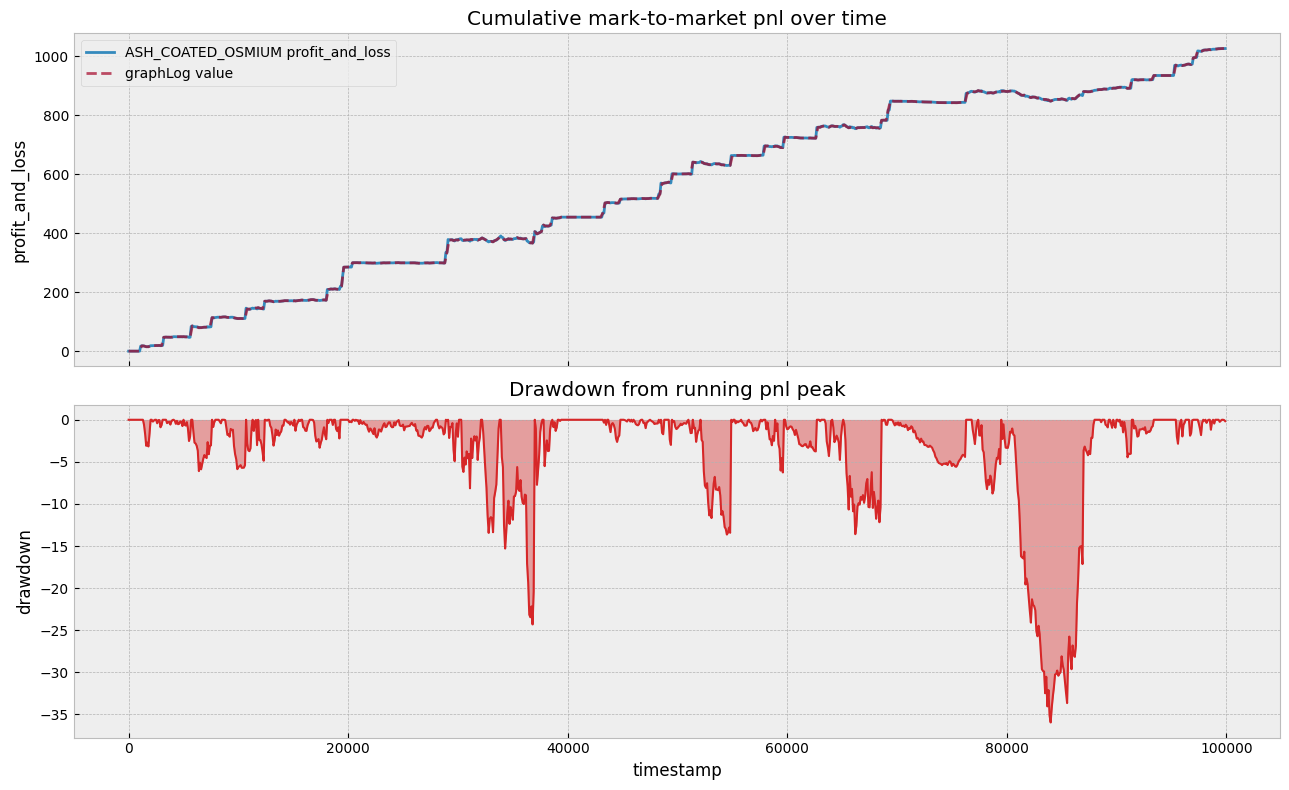

,day,start_pnl,end_pnl,pnl_change,max_drawdown
0,0,0.0,1025.4375,1025.4375,-35.957031


,graph_log_abs_diff
count,500.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [5]:
daily_pnl = (
    ash.groupby("day")
    .agg(
        start_pnl=("profit_and_loss", "first"),
        end_pnl=("profit_and_loss", "last"),
        pnl_change=("profit_and_loss", lambda s: s.iloc[-1] - s.iloc[0]),
        max_drawdown=("drawdown", "min"),
    )
    .reset_index()
)

graph_compare = pd.DataFrame()
if not graph_df.empty:
    graph_compare = ash[["timestamp", "profit_and_loss"]].merge(
        graph_df.rename(columns={"value": "graph_value"}),
        on="timestamp",
        how="inner",
    )
    if not graph_compare.empty:
        graph_compare["abs_diff"] = (graph_compare["profit_and_loss"] - graph_compare["graph_value"]).abs()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(ash["timestamp"], ash["profit_and_loss"], label=f"{TARGET_PRODUCT} profit_and_loss", linewidth=2)
if not graph_compare.empty:
    axes[0].plot(graph_compare["timestamp"], graph_compare["graph_value"], linestyle="--", alpha=0.7, label="graphLog value")
axes[0].set_title("Cumulative mark-to-market pnl over time")
axes[0].set_ylabel("profit_and_loss")
axes[0].legend(loc="best")

axes[1].fill_between(ash["timestamp"], ash["drawdown"], 0, color="tab:red", alpha=0.4)
axes[1].plot(ash["timestamp"], ash["drawdown"], color="tab:red", linewidth=1.5)
axes[1].set_title("Drawdown from running pnl peak")
axes[1].set_xlabel("timestamp")
axes[1].set_ylabel("drawdown")
plt.tight_layout()
plt.show()

display(daily_pnl)
if not graph_compare.empty:
    display(graph_compare["abs_diff"].describe().to_frame("graph_log_abs_diff"))


## Market-state diagnostics

These plots track the market environment the strategy faced: price path, spread, visible depth, and top-of-book imbalance.


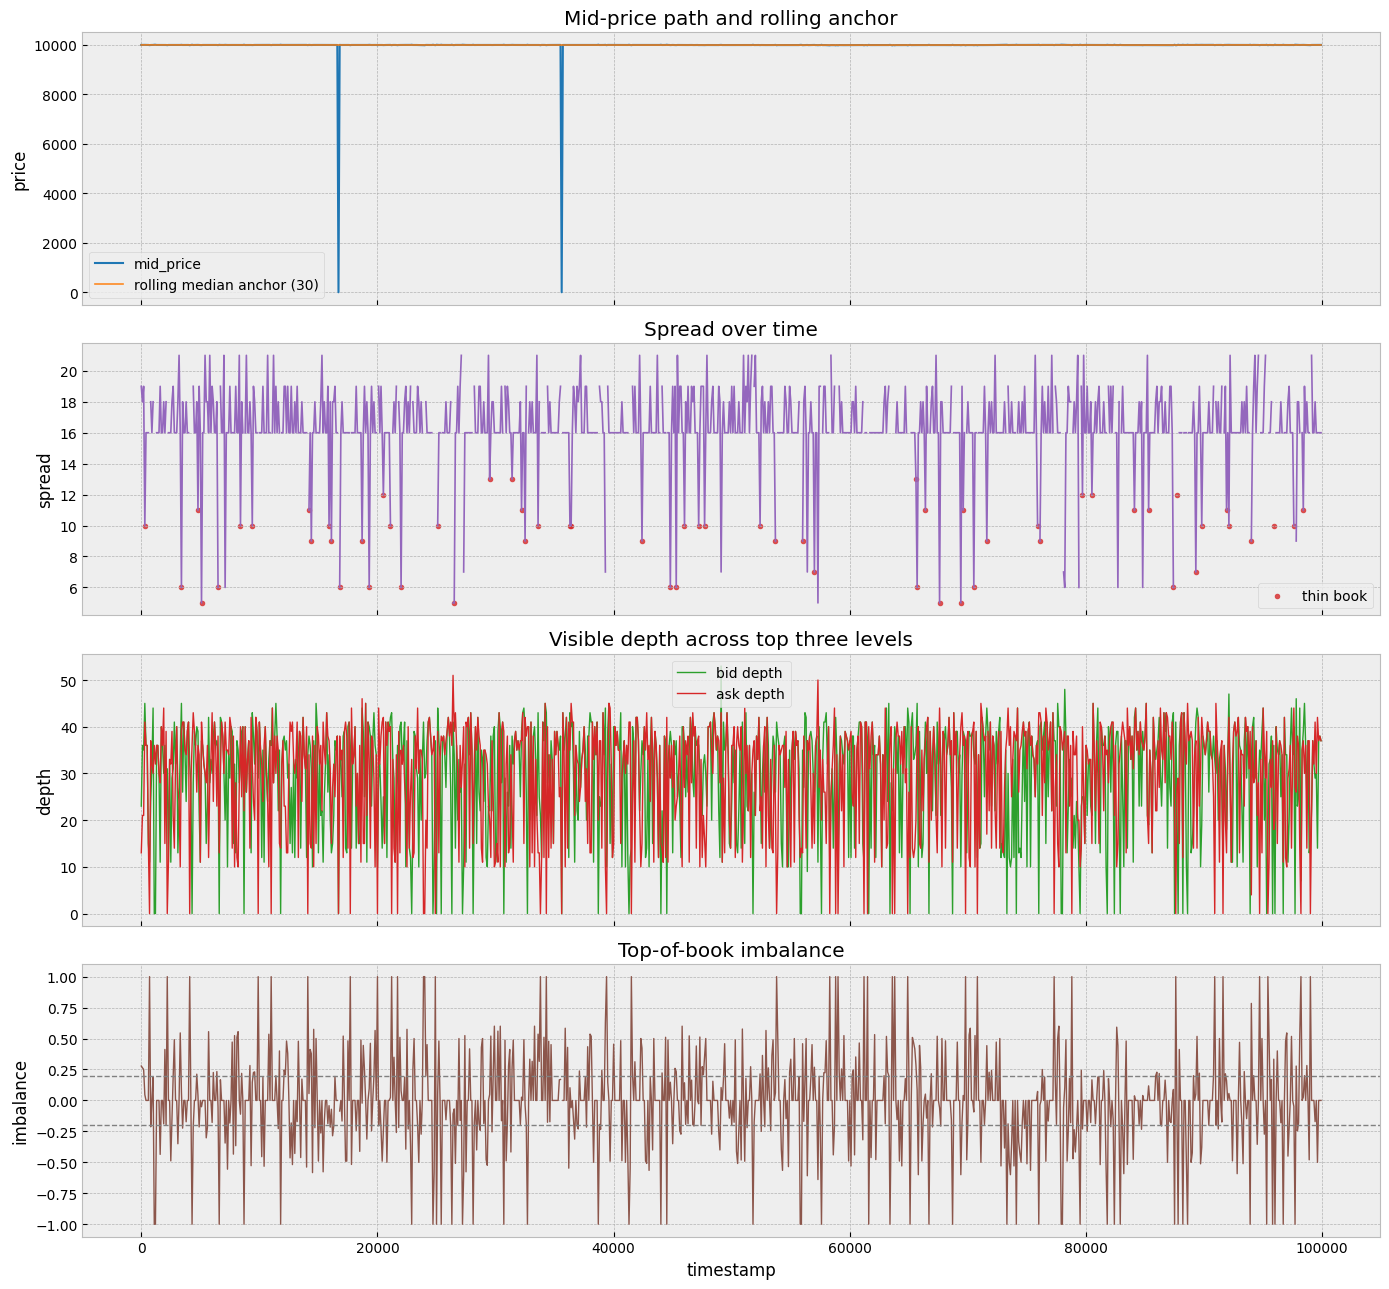

,metric,value
0,median_spread,16.000000
1,mean_spread,16.253829
2,one_sided_book_rate,0.086000
3,thin_book_rate,0.060000
4,median_visible_depth_3,61.000000
5,mean_visible_depth_3,59.020000
6,high_volatility_threshold,3.900000
7,low_volatility_threshold,0.800000


In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

axes[0].plot(ash["timestamp"], ash["mid_price"], color="tab:blue", linewidth=1.5)
axes[0].plot(ash["timestamp"], ash["anchor"], color="tab:orange", linewidth=1.2, alpha=0.9)
axes[0].set_title("Mid-price path and rolling anchor")
axes[0].set_ylabel("price")
axes[0].legend(["mid_price", f"rolling median anchor ({ANCHOR_LOOKBACK})"], loc="best")

axes[1].plot(ash["timestamp"], ash["spread"], color="tab:purple", linewidth=1.2)
axes[1].scatter(
    ash.loc[ash["thin_book"], "timestamp"],
    ash.loc[ash["thin_book"], "spread"],
    color="tab:red",
    s=12,
    alpha=0.8,
    label="thin book",
)
axes[1].set_title("Spread over time")
axes[1].set_ylabel("spread")
axes[1].legend(loc="best")

axes[2].plot(ash["timestamp"], ash["visible_bid_depth_3"], color="tab:green", linewidth=1.0)
axes[2].plot(ash["timestamp"], ash["visible_ask_depth_3"], color="tab:red", linewidth=1.0)
axes[2].set_title("Visible depth across top three levels")
axes[2].set_ylabel("depth")
axes[2].legend(["bid depth", "ask depth"], loc="best")

axes[3].plot(ash["timestamp"], ash["imbalance_3"], color="tab:brown", linewidth=1.0)
axes[3].axhline(0.20, color="grey", linestyle="--", linewidth=1)
axes[3].axhline(-0.20, color="grey", linestyle="--", linewidth=1)
axes[3].set_title("Top-of-book imbalance")
axes[3].set_ylabel("imbalance")
axes[3].set_xlabel("timestamp")

plt.tight_layout()
plt.show()

market_state_summary = pd.DataFrame(
    {
        "metric": [
            "median_spread",
            "mean_spread",
            "one_sided_book_rate",
            "thin_book_rate",
            "median_visible_depth_3",
            "mean_visible_depth_3",
            "high_volatility_threshold",
            "low_volatility_threshold",
        ],
        "value": [
            ash["spread"].median(),
            ash["spread"].mean(),
            ash["one_sided_book"].mean(),
            ash["thin_book"].mean(),
            ash["visible_depth_3"].median(),
            ash["visible_depth_3"].mean(),
            ash.attrs["high_vol_threshold"],
            ash.attrs["low_vol_threshold"],
        ],
    }
)

display(market_state_summary)


## Regime reconstruction and segmentation

This section reconstructs each run's public-state regime logic using the threshold inferred from its sibling submission file, then compares backtest 2 against backtest 1 rather than against a stale hypothetical threshold.


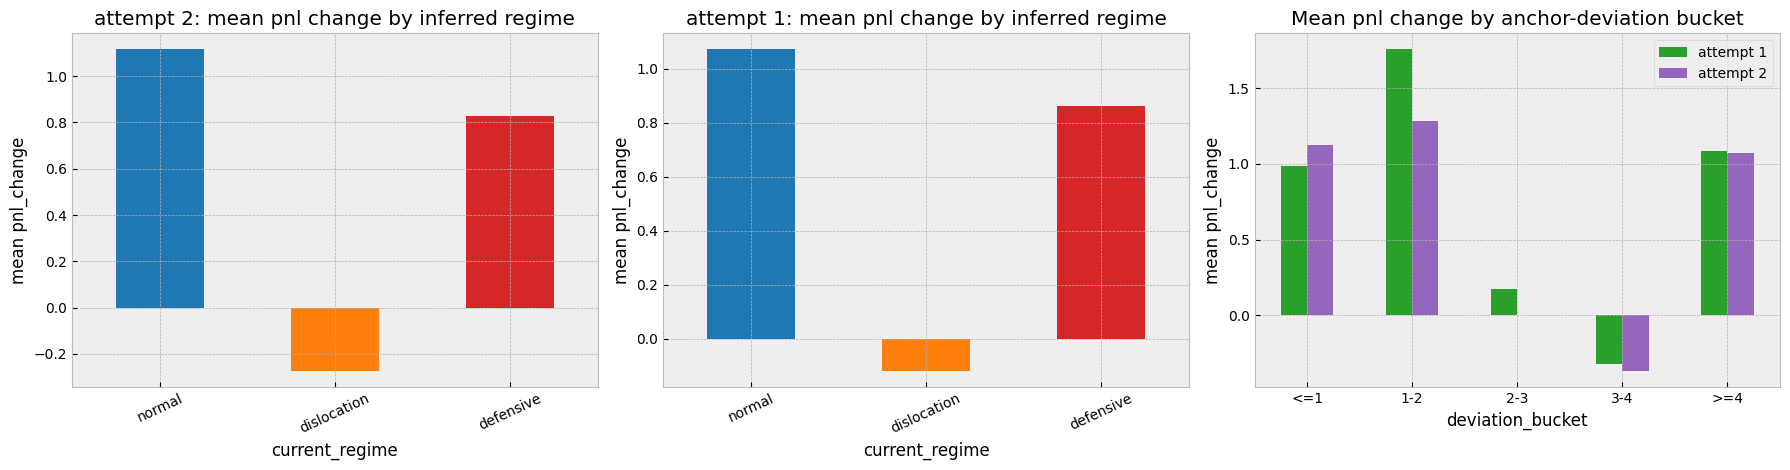

,rows,share,mean_pnl_change,median_pnl_change,sum_pnl_change,negative_pnl_change_rate
segment,,,,,,
stable_balanced_period,310,0.310,1.349537,0.021484,418.356445,0.403226
one_sided_book,86,0.086,0.706066,0.007812,60.721680,0.441860
thin_book,60,0.060,1.004883,0.100586,60.292969,0.450000
high_volatility,209,0.209,0.401194,0.000000,83.849609,0.459330
low_volatility,222,0.222,1.660447,0.009277,368.619141,0.409910
dislocation_|dev|>=3,34,0.034,-0.272834,-0.128906,-9.276367,0.558824


,rows,share,mean_pnl_change,median_pnl_change,sum_pnl_change,negative_pnl_change_rate
segment,,,,,,
stable_balanced_period,316,0.316,1.378220,0.052246,435.517578,0.411392
one_sided_book,86,0.086,0.721089,0.020508,62.013672,0.453488
thin_book,60,0.060,1.060840,0.034180,63.650391,0.450000
high_volatility,209,0.209,0.441668,0.026367,92.308594,0.459330
low_volatility,222,0.222,1.829669,0.051758,406.186523,0.396396
dislocation_|dev|>=5,5,0.005,-0.118750,0.445312,-0.593750,0.400000


,count,mean,median,sum
current_regime,,,,
defensive,146,0.828867,0.007812,121.014648
dislocation,34,-0.272834,-0.128906,-9.276367
normal,819,1.115628,0.000000,913.699219


,count,mean,median,sum
current_regime,,,,
defensive,146,0.860713,0.020508,125.664062
dislocation,5,-0.118750,0.445312,-0.593750
normal,848,1.072035,0.041016,909.085938


,attempt 1,attempt 2,delta_current_minus_baseline
deviation_bucket,,,
<=1,0.983690,1.127248,0.143558
1-2,1.756240,1.280347,-0.475893
2-3,0.177623,0.001297,-0.176325
3-4,-0.317522,-0.365513,-0.047991
>=4,1.084840,1.070589,-0.014251


In [7]:
def segment_stats(df: pd.DataFrame, mask: pd.Series, label: str) -> dict:
    sample = df.loc[mask].copy()
    return {
        "segment": label,
        "rows": int(mask.sum()),
        "share": float(mask.mean()),
        "mean_pnl_change": float(sample["pnl_change"].mean()) if not sample.empty else np.nan,
        "median_pnl_change": float(sample["pnl_change"].median()) if not sample.empty else np.nan,
        "sum_pnl_change": float(sample["pnl_change"].sum()) if not sample.empty else np.nan,
        "negative_pnl_change_rate": float((sample["pnl_change"] < 0).mean()) if not sample.empty else np.nan,
    }


current_segment_summary = pd.DataFrame(
    [
        segment_stats(ash, ash["stable_balanced_period"], "stable_balanced_period"),
        segment_stats(ash, ash["one_sided_book"], "one_sided_book"),
        segment_stats(ash, ash["thin_book"], "thin_book"),
        segment_stats(ash, ash["high_volatility"], "high_volatility"),
        segment_stats(ash, ash["low_volatility"], "low_volatility"),
        segment_stats(ash, ash["current_dislocation_flag"], f"dislocation_|dev|>={CURRENT_DISLOCATION_THRESHOLD:g}"),
    ]
).set_index("segment")

baseline_segment_summary = pd.DataFrame(
    [
        segment_stats(baseline_ash, baseline_ash["stable_balanced_period"], "stable_balanced_period"),
        segment_stats(baseline_ash, baseline_ash["one_sided_book"], "one_sided_book"),
        segment_stats(baseline_ash, baseline_ash["thin_book"], "thin_book"),
        segment_stats(baseline_ash, baseline_ash["high_volatility"], "high_volatility"),
        segment_stats(baseline_ash, baseline_ash["low_volatility"], "low_volatility"),
        segment_stats(baseline_ash, baseline_ash["current_dislocation_flag"], f"dislocation_|dev|>={BASELINE_DISLOCATION_THRESHOLD:g}"),
    ]
).set_index("segment")

current_regime_summary = ash.groupby("current_regime")["pnl_change"].agg(["count", "mean", "median", "sum"])
baseline_regime_summary = baseline_ash.groupby("current_regime")["pnl_change"].agg(["count", "mean", "median", "sum"])
current_deviation_bucket_summary = ash.groupby("deviation_bucket", observed=False)["pnl_change"].agg(["count", "mean", "median", "sum"])
baseline_deviation_bucket_summary = baseline_ash.groupby("deviation_bucket", observed=False)["pnl_change"].agg(["count", "mean", "median", "sum"])

deviation_bucket_mean_comparison = pd.DataFrame(
    {
        BASELINE_RUN_LABEL: baseline_deviation_bucket_summary["mean"],
        CURRENT_RUN_LABEL: current_deviation_bucket_summary["mean"],
    }
)
deviation_bucket_mean_comparison["delta_current_minus_baseline"] = (
    deviation_bucket_mean_comparison[CURRENT_RUN_LABEL] - deviation_bucket_mean_comparison[BASELINE_RUN_LABEL]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

current_regime_summary["mean"].reindex(["normal", "dislocation", "defensive"]).plot(
    kind="bar", ax=axes[0], color=["tab:blue", "tab:orange", "tab:red"]
)
axes[0].set_title(f"{CURRENT_RUN_LABEL}: mean pnl change by inferred regime")
axes[0].set_ylabel("mean pnl_change")
axes[0].tick_params(axis="x", rotation=25)

baseline_regime_summary["mean"].reindex(["normal", "dislocation", "defensive"]).plot(
    kind="bar", ax=axes[1], color=["tab:blue", "tab:orange", "tab:red"]
)
axes[1].set_title(f"{BASELINE_RUN_LABEL}: mean pnl change by inferred regime")
axes[1].set_ylabel("mean pnl_change")
axes[1].tick_params(axis="x", rotation=25)

deviation_bucket_mean_comparison[[BASELINE_RUN_LABEL, CURRENT_RUN_LABEL]].plot(
    kind="bar", ax=axes[2], color=["tab:green", "tab:purple"]
)
axes[2].set_title("Mean pnl change by anchor-deviation bucket")
axes[2].set_ylabel("mean pnl_change")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(loc="best")

plt.tight_layout()
plt.show()

display(current_segment_summary)
display(baseline_segment_summary)
display(current_regime_summary)
display(baseline_regime_summary)
display(deviation_bucket_mean_comparison)


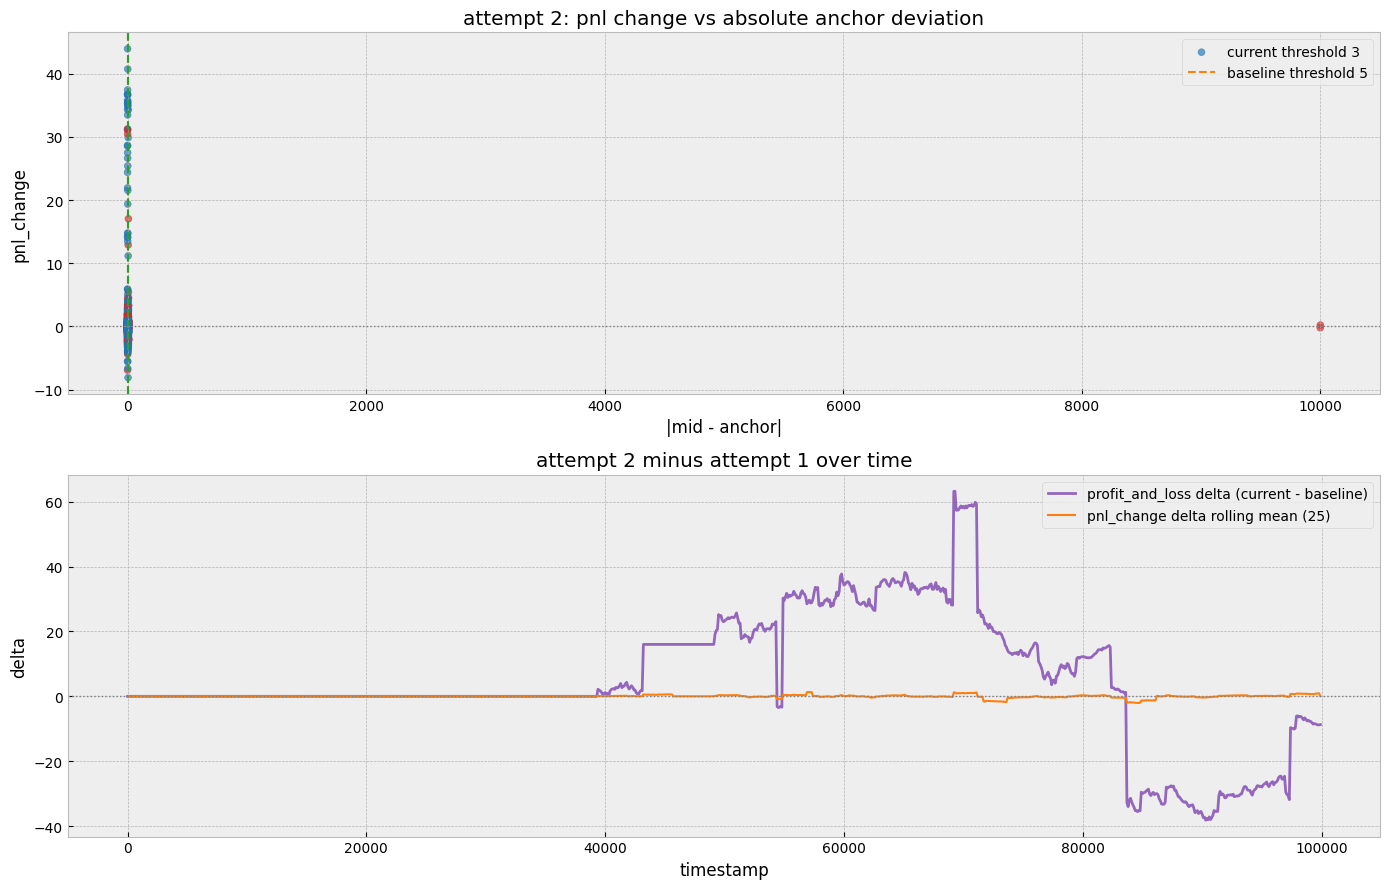

In [8]:
baseline_threshold_flag_on_current_run = ash["tradeable_book"] & (
    ash["abs_anchor_deviation"] >= BASELINE_DISLOCATION_THRESHOLD
)

aligned_compare = ash[
    [
        "day",
        "timestamp",
        "profit_and_loss",
        "pnl_change",
        "abs_anchor_deviation",
        "current_dislocation_flag",
    ]
].merge(
    baseline_ash[
        [
            "day",
            "timestamp",
            "profit_and_loss",
            "pnl_change",
            "abs_anchor_deviation",
            "current_dislocation_flag",
        ]
    ],
    on=["day", "timestamp"],
    suffixes=("_current", "_baseline"),
)
assert len(aligned_compare) == len(ash) == len(baseline_ash), "Aligned comparison dropped timestamps unexpectedly."

aligned_compare["profit_and_loss_delta_current_minus_baseline"] = (
    aligned_compare["profit_and_loss_current"] - aligned_compare["profit_and_loss_baseline"]
)
aligned_compare["pnl_change_delta_current_minus_baseline"] = (
    aligned_compare["pnl_change_current"] - aligned_compare["pnl_change_baseline"]
)
aligned_compare["pnl_change_delta_rolling_25"] = aligned_compare[
    "pnl_change_delta_current_minus_baseline"
].rolling(25, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

axes[0].scatter(
    ash["abs_anchor_deviation"],
    ash["pnl_change"],
    c=np.where(ash["high_volatility"], "tab:red", "tab:blue"),
    alpha=0.65,
    s=24,
)
axes[0].axvline(CURRENT_DISLOCATION_THRESHOLD, color="tab:orange", linestyle="--", linewidth=1.5)
axes[0].axvline(BASELINE_DISLOCATION_THRESHOLD, color="tab:green", linestyle="--", linewidth=1.5)
axes[0].axhline(0, color="grey", linestyle=":", linewidth=1)
axes[0].set_title(f"{CURRENT_RUN_LABEL}: pnl change vs absolute anchor deviation")
axes[0].set_xlabel("|mid - anchor|")
axes[0].set_ylabel("pnl_change")
axes[0].legend(
    [
        f"current threshold {CURRENT_DISLOCATION_THRESHOLD:g}",
        f"baseline threshold {BASELINE_DISLOCATION_THRESHOLD:g}",
    ],
    loc="best",
)

axes[1].plot(
    aligned_compare["timestamp"],
    aligned_compare["profit_and_loss_delta_current_minus_baseline"],
    color="tab:purple",
    linewidth=2,
    label="profit_and_loss delta (current - baseline)",
)
axes[1].plot(
    aligned_compare["timestamp"],
    aligned_compare["pnl_change_delta_rolling_25"],
    color="tab:orange",
    linewidth=1.5,
    label="pnl_change delta rolling mean (25)",
)
axes[1].axhline(0, color="grey", linestyle=":", linewidth=1)
axes[1].set_title(f"{CURRENT_RUN_LABEL} minus {BASELINE_RUN_LABEL} over time")
axes[1].set_xlabel("timestamp")
axes[1].set_ylabel("delta")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()


## Failure-mode tables

Without fills and inventory, the best direct clues are where mark-to-market pnl weakens, how often the strategy faces one-sided or thin books, and whether dislocation logic activates when the market deviates from the rolling anchor.


In [9]:
state_vs_pnl = pd.DataFrame(
    [
        segment_stats(ash, ash["stable_balanced_period"], "stable_balanced_period"),
        segment_stats(ash, ash["one_sided_book"], "one_sided_book"),
        segment_stats(ash, ash["thin_book"], "thin_book"),
        segment_stats(ash, ash["high_volatility"], "high_volatility"),
        segment_stats(ash, ash["current_dislocation_flag"], f"current_dislocation_abs_dev_ge_{CURRENT_DISLOCATION_THRESHOLD:g}"),
        segment_stats(baseline_ash, baseline_ash["current_dislocation_flag"], f"baseline_dislocation_abs_dev_ge_{BASELINE_DISLOCATION_THRESHOLD:g}"),
    ]
).set_index("segment")

worst_mark_to_market_steps = ash.nsmallest(12, "pnl_change")[
    [
        "day",
        "timestamp",
        "profit_and_loss",
        "pnl_change",
        "mid_price",
        "spread",
        "min_top_depth",
        "visible_depth_3",
        "imbalance_3",
        "one_sided_book",
        "thin_book",
        "rolling_abs_move",
        "abs_anchor_deviation",
        "current_regime",
    ]
]

correlation_columns = [
    "pnl_change",
    "spread",
    "visible_depth_3",
    "imbalance_3",
    "abs_mid_change",
    "rolling_abs_move",
    "abs_anchor_deviation",
]
correlation_summary = ash[correlation_columns].corr(numeric_only=True)[["pnl_change"]].sort_values("pnl_change")

comparison_metrics = pd.DataFrame(
    {
        BASELINE_RUN_LABEL: pd.Series(
            {
                "total_pnl": float(baseline_ash["profit_and_loss"].iloc[-1] - baseline_ash["profit_and_loss"].iloc[0]),
                "max_drawdown": float(baseline_ash["drawdown"].min()),
                "dislocation_threshold": BASELINE_DISLOCATION_THRESHOLD,
                "dislocation_rows": int(baseline_ash["current_dislocation_flag"].sum()),
                "dislocation_share": float(baseline_ash["current_dislocation_flag"].mean()),
                "dislocation_mean_pnl_change": float(baseline_ash.loc[baseline_ash["current_dislocation_flag"], "pnl_change"].mean()),
                "dislocation_median_pnl_change": float(baseline_ash.loc[baseline_ash["current_dislocation_flag"], "pnl_change"].median()),
                "dislocation_sum_pnl_change": float(baseline_ash.loc[baseline_ash["current_dislocation_flag"], "pnl_change"].sum()),
                "mean_pnl_change_top_vol_quintile": float(baseline_ash.loc[baseline_ash["high_volatility"], "pnl_change"].mean()),
                "mean_pnl_change_rest_of_run": float(baseline_ash.loc[~baseline_ash["high_volatility"], "pnl_change"].mean()),
            }
        ),
        CURRENT_RUN_LABEL: pd.Series(
            {
                "total_pnl": float(ash["profit_and_loss"].iloc[-1] - ash["profit_and_loss"].iloc[0]),
                "max_drawdown": float(ash["drawdown"].min()),
                "dislocation_threshold": CURRENT_DISLOCATION_THRESHOLD,
                "dislocation_rows": int(ash["current_dislocation_flag"].sum()),
                "dislocation_share": float(ash["current_dislocation_flag"].mean()),
                "dislocation_mean_pnl_change": float(ash.loc[ash["current_dislocation_flag"], "pnl_change"].mean()),
                "dislocation_median_pnl_change": float(ash.loc[ash["current_dislocation_flag"], "pnl_change"].median()),
                "dislocation_sum_pnl_change": float(ash.loc[ash["current_dislocation_flag"], "pnl_change"].sum()),
                "mean_pnl_change_top_vol_quintile": float(ash.loc[ash["high_volatility"], "pnl_change"].mean()),
                "mean_pnl_change_rest_of_run": float(ash.loc[~ash["high_volatility"], "pnl_change"].mean()),
            }
        ),
    }
)
comparison_metrics["delta_current_minus_baseline"] = comparison_metrics[CURRENT_RUN_LABEL] - comparison_metrics[BASELINE_RUN_LABEL]

aligned_delta_extremes = aligned_compare.nsmallest(12, "profit_and_loss_delta_current_minus_baseline")[
    [
        "timestamp",
        "profit_and_loss_baseline",
        "profit_and_loss_current",
        "profit_and_loss_delta_current_minus_baseline",
        "pnl_change_baseline",
        "pnl_change_current",
        "pnl_change_delta_current_minus_baseline",
        "abs_anchor_deviation_baseline",
        "abs_anchor_deviation_current",
        "current_dislocation_flag_baseline",
        "current_dislocation_flag_current",
    ]
]

display(state_vs_pnl)
display(correlation_summary)
display(comparison_metrics)
display(deviation_bucket_mean_comparison)
display(aligned_delta_extremes)
display(worst_mark_to_market_steps)


,rows,share,mean_pnl_change,median_pnl_change,sum_pnl_change,negative_pnl_change_rate
segment,,,,,,
stable_balanced_period,310,0.310,1.349537,0.021484,418.356445,0.403226
one_sided_book,86,0.086,0.706066,0.007812,60.721680,0.441860
thin_book,60,0.060,1.004883,0.100586,60.292969,0.450000
high_volatility,209,0.209,0.401194,0.000000,83.849609,0.459330
current_dislocation_abs_dev_ge_3,34,0.034,-0.272834,-0.128906,-9.276367,0.558824
baseline_dislocation_abs_dev_ge_5,5,0.005,-0.118750,0.445312,-0.593750,0.400000


,pnl_change
rolling_abs_move,-0.025873
abs_anchor_deviation,-0.008267
abs_mid_change,-0.008148
visible_depth_3,-0.008139
imbalance_3,0.007392
spread,0.028434
pnl_change,1.000000


,attempt 1,attempt 2,delta_current_minus_baseline
total_pnl,1034.156250,1025.437500,-8.718750
max_drawdown,-36.007812,-35.957031,0.050781
dislocation_threshold,5.000000,3.000000,-2.000000
dislocation_rows,5.000000,34.000000,29.000000
dislocation_share,0.005000,0.034000,0.029000
dislocation_mean_pnl_change,-0.118750,-0.272834,-0.154084
dislocation_median_pnl_change,0.445312,-0.128906,-0.574219
dislocation_sum_pnl_change,-0.593750,-9.276367,-8.682617
mean_pnl_change_top_vol_quintile,0.441668,0.401194,-0.040474
mean_pnl_change_rest_of_run,1.192212,1.191883,-0.000329


,attempt 1,attempt 2,delta_current_minus_baseline
deviation_bucket,,,
<=1,0.983690,1.127248,0.143558
1-2,1.756240,1.280347,-0.475893
2-3,0.177623,0.001297,-0.176325
3-4,-0.317522,-0.365513,-0.047991
>=4,1.084840,1.070589,-0.014251


,timestamp,profit_and_loss_baseline,profit_and_loss_current,profit_and_loss_delta_current_minus_baseline,pnl_change_baseline,pnl_change_current,pnl_change_delta_current_minus_baseline,abs_anchor_deviation_baseline,abs_anchor_deviation_current,current_dislocation_flag_baseline,current_dislocation_flag_current
903,90300,932.921875,894.751953,-38.169922,2.253906,1.349609,-0.904297,2.0,2.0,False,False
905,90500,932.574219,894.542969,-38.031250,0.855469,0.511719,-0.343750,2.0,2.0,False,False
907,90700,932.468750,894.482422,-37.986328,2.039062,1.224609,-0.814453,1.0,1.0,False,False
904,90400,931.718750,894.031250,-37.687500,-1.203125,-0.720703,0.482422,0.0,0.0,False,False
908,90800,931.195312,893.718750,-37.476562,-1.273438,-0.763672,0.509766,2.5,2.5,False,False
901,90100,931.007812,893.603516,-37.404297,2.742188,1.642578,-1.099609,2.0,2.0,False,False
902,90200,930.667969,893.402344,-37.265625,-0.339844,-0.201172,0.138672,1.5,1.5,False,False
906,90600,930.429688,893.257812,-37.171875,-2.144531,-1.285156,0.859375,1.0,1.0,False,False
909,90900,929.125000,892.476562,-36.648438,-2.070312,-1.242188,0.828125,7.0,7.0,False,False
900,90000,928.265625,891.960938,-36.304688,2.031250,1.218750,-0.812500,2.0,2.0,False,False


,day,timestamp,profit_and_loss,pnl_change,mid_price,spread,min_top_depth,visible_depth_3,imbalance_3,one_sided_book,thin_book,rolling_abs_move,abs_anchor_deviation,current_regime
363,0,36300,373.296875,-8.117188,9997.0,10.0,5.0,78.0,0.102564,False,True,0.8,4.00,defensive
342,0,34200,377.828125,-6.929688,10001.0,16.0,15.0,90.0,0.000000,False,False,4.2,0.00,normal
372,0,37200,397.218750,-6.656250,9999.5,21.0,27.0,54.0,0.000000,False,False,1.5,1.50,normal
304,0,30400,375.265625,-5.570312,10001.0,16.0,10.0,50.0,0.600000,False,False,0.0,0.00,normal
379,0,37900,421.828125,-5.507812,10000.0,16.0,11.0,76.0,0.000000,False,False,1.2,1.00,normal
340,0,34000,385.968750,-4.421875,10002.0,16.0,13.0,82.0,0.000000,False,False,5.5,1.00,normal
678,0,67800,756.894531,-4.246094,9996.0,18.0,10.0,40.0,0.500000,False,False,2.1,1.00,normal
311,0,31100,372.695312,-4.078125,9999.0,18.0,13.0,36.0,0.277778,False,False,4.2,2.00,normal
654,0,65400,761.039062,-3.937500,9996.0,16.0,12.0,45.0,0.466667,False,False,4.8,0.00,normal
817,0,81700,863.539062,-3.890625,9999.0,16.0,10.0,44.0,-0.545455,False,False,0.6,2.00,normal


## Decision

The logic below converts the measured attempt-2-versus-attempt-1 deltas into exactly one next strategy change. The recommendation is computed from the comparison metrics, not hard-coded prose.


In [10]:
total_pnl = float(ash["profit_and_loss"].iloc[-1] - ash["profit_and_loss"].iloc[0])
baseline_total_pnl = float(baseline_ash["profit_and_loss"].iloc[-1] - baseline_ash["profit_and_loss"].iloc[0])
max_drawdown = float(ash["drawdown"].min())
baseline_max_drawdown = float(baseline_ash["drawdown"].min())

dislocation_rows = int(ash["current_dislocation_flag"].sum())
baseline_dislocation_rows = int(baseline_ash["current_dislocation_flag"].sum())
dislocation_share = float(ash["current_dislocation_flag"].mean())
baseline_dislocation_share = float(baseline_ash["current_dislocation_flag"].mean())
dislocation_mean = float(ash.loc[ash["current_dislocation_flag"], "pnl_change"].mean())
baseline_dislocation_mean = float(baseline_ash.loc[baseline_ash["current_dislocation_flag"], "pnl_change"].mean())
dislocation_median = float(ash.loc[ash["current_dislocation_flag"], "pnl_change"].median())
baseline_dislocation_median = float(baseline_ash.loc[baseline_ash["current_dislocation_flag"], "pnl_change"].median())
dislocation_sum = float(ash.loc[ash["current_dislocation_flag"], "pnl_change"].sum())
baseline_dislocation_sum = float(baseline_ash.loc[baseline_ash["current_dislocation_flag"], "pnl_change"].sum())

high_vol_mean = float(ash.loc[ash["high_volatility"], "pnl_change"].mean())
baseline_high_vol_mean = float(baseline_ash.loc[baseline_ash["high_volatility"], "pnl_change"].mean())
rest_vol_mean = float(ash.loc[~ash["high_volatility"], "pnl_change"].mean())
baseline_rest_vol_mean = float(baseline_ash.loc[~baseline_ash["high_volatility"], "pnl_change"].mean())

bucket_2_3_mean = float(current_deviation_bucket_summary.loc["2-3", "mean"])
baseline_bucket_2_3_mean = float(baseline_deviation_bucket_summary.loc["2-3", "mean"])
bucket_3_4_mean = float(current_deviation_bucket_summary.loc["3-4", "mean"])
baseline_bucket_3_4_mean = float(baseline_deviation_bucket_summary.loc["3-4", "mean"])
bucket_ge4_mean = float(current_deviation_bucket_summary.loc[">=4", "mean"])
baseline_bucket_ge4_mean = float(baseline_deviation_bucket_summary.loc[">=4", "mean"])

threshold_change_only = (
    len(changed_strategy_fields) == 1 and changed_strategy_fields["parameter"].iloc[0] == "dislocation_threshold"
)
threshold_experiment_failed = (
    threshold_change_only
    and total_pnl < baseline_total_pnl
    and abs(max_drawdown - baseline_max_drawdown) < 1.0
    and dislocation_rows > baseline_dislocation_rows
    and dislocation_mean < baseline_dislocation_mean
    and high_vol_mean <= baseline_high_vol_mean
)

if threshold_experiment_failed:
    next_change = (
        f"Raise dislocation_threshold from {CURRENT_DISLOCATION_THRESHOLD:.1f} back to {BASELINE_DISLOCATION_THRESHOLD:.1f} "
        f"while leaving strong_dislocation_buffer = {CURRENT_STRONG_DISLOCATION_BUFFER:.1f} unchanged."
    )
    why_this_change = (
        "The 5.0 -> 3.0 threshold experiment increased dislocation activation materially, but total pnl fell, drawdown barely improved, "
        "and the dislocation regime stayed loss-making. Reverting the threshold is the smallest high-value change because it directly undoes the only confirmed code change in this run."
    )
else:
    next_change = "Do not revert the dislocation threshold yet; gather another controlled run before changing this rule."
    why_this_change = "The measured attempt-2-versus-attempt-1 deltas were not strong enough to justify a reversal from this file alone."

what_data_says = [
    f"Only inferred strategy-config change between {BASELINE_RUN_LABEL} and {CURRENT_RUN_LABEL} was dislocation_threshold {BASELINE_DISLOCATION_THRESHOLD:.1f} -> {CURRENT_DISLOCATION_THRESHOLD:.1f}.",
    f"Total pnl moved from {baseline_total_pnl} to {total_pnl} ({total_pnl - baseline_total_pnl:+.5f}).",
    f"Max drawdown moved from {baseline_max_drawdown} to {max_drawdown} ({max_drawdown - baseline_max_drawdown:+.8f}).",
    f"Dislocation activation increased from {baseline_dislocation_rows} rows ({baseline_dislocation_share:.2%}) to {dislocation_rows} rows ({dislocation_share:.2%}).",
    f"Mean dislocation pnl_change worsened from {baseline_dislocation_mean} to {dislocation_mean}; median changed from {baseline_dislocation_median} to {dislocation_median}; sum changed from {baseline_dislocation_sum} to {dislocation_sum}.",
    f"High-volatility mean pnl_change weakened from {baseline_high_vol_mean} to {high_vol_mean}, while the rest of the run stayed nearly flat at {baseline_rest_vol_mean} vs {rest_vol_mean}.",
]

likely_caused_result = [
    "Lowering the threshold to 3.0 moved many more rows into the dislocation regime, but those rows remained loss-making on average.",
    "The weak 3-4 deviation bucket did not improve after the threshold change, and the additional dislocation rows did not translate into better mark-to-market behavior.",
    "Because the market path is identical across both runs and the only inferred code change is the threshold, the cleanest explanation is that the lower trigger made the regime fire more often without improving outcomes."
]

next_run_metrics = pd.Series(
    {
        "total_pnl": total_pnl,
        "max_drawdown": max_drawdown,
        "dislocation_threshold": CURRENT_DISLOCATION_THRESHOLD,
        "dislocation_rows": dislocation_rows,
        "dislocation_share": dislocation_share,
        "dislocation_mean_pnl_change": dislocation_mean,
        "dislocation_median_pnl_change": dislocation_median,
        "dislocation_sum_pnl_change": dislocation_sum,
        "mean_pnl_change_top_vol_quintile": high_vol_mean,
        "mean_pnl_change_rest_of_run": rest_vol_mean,
        "deviation_bucket_mean_2_3": bucket_2_3_mean,
        "deviation_bucket_mean_3_4": bucket_3_4_mean,
        "deviation_bucket_mean_ge4": bucket_ge4_mean,
        "one_sided_book_rate": float(ash["one_sided_book"].mean()),
        "thin_book_rate": float(ash["thin_book"].mean()),
    },
    name="compare_on_next_run",
)

display(next_run_metrics.to_frame())

conclusion_lines = [
    "## Evidence-based conclusion",
    "1. **What the data says**",
    *[f"   - {item}" for item in what_data_says],
    "2. **What likely caused the current result**",
    *[f"   - {item}" for item in likely_caused_result],
    "3. **What single change should be made next**",
    f"   - {next_change}",
    "4. **Why that change is the highest-value next experiment**",
    f"   - {why_this_change}",
    "",
    "This notebook intentionally avoids stronger claims about fills or inventory because those fields are absent from the JSON.",
]

display(Markdown(chr(10).join(conclusion_lines)))


,compare_on_next_run
total_pnl,1025.437500
max_drawdown,-35.957031
dislocation_threshold,3.000000
dislocation_rows,34.000000
dislocation_share,0.034000
dislocation_mean_pnl_change,-0.272834
dislocation_median_pnl_change,-0.128906
dislocation_sum_pnl_change,-9.276367
mean_pnl_change_top_vol_quintile,0.401194
mean_pnl_change_rest_of_run,1.191883


## Evidence-based conclusion
1. **What the data says**
   - Only inferred strategy-config change between attempt 1 and attempt 2 was dislocation_threshold 5.0 -> 3.0.
   - Total pnl moved from 1034.15625 to 1025.4375 (-8.71875).
   - Max drawdown moved from -36.0078125 to -35.95703125 (+0.05078125).
   - Dislocation activation increased from 5 rows (0.50%) to 34 rows (3.40%).
   - Mean dislocation pnl_change worsened from -0.11875 to -0.27283432904411764; median changed from 0.4453125 to -0.12890625; sum changed from -0.59375 to -9.2763671875.
   - High-volatility mean pnl_change weakened from 0.44166791267942584 to 0.4011943032296651, while the rest of the run stayed nearly flat at 1.1922122231012657 vs 1.1918834058544303.
2. **What likely caused the current result**
   - Lowering the threshold to 3.0 moved many more rows into the dislocation regime, but those rows remained loss-making on average.
   - The weak 3-4 deviation bucket did not improve after the threshold change, and the additional dislocation rows did not translate into better mark-to-market behavior.
   - Because the market path is identical across both runs and the only inferred code change is the threshold, the cleanest explanation is that the lower trigger made the regime fire more often without improving outcomes.
3. **What single change should be made next**
   - Raise dislocation_threshold from 3.0 back to 5.0 while leaving strong_dislocation_buffer = 2.0 unchanged.
4. **Why that change is the highest-value next experiment**
   - The 5.0 -> 3.0 threshold experiment increased dislocation activation materially, but total pnl fell, drawdown barely improved, and the dislocation regime stayed loss-making. Reverting the threshold is the smallest high-value change because it directly undoes the only confirmed code change in this run.

This notebook intentionally avoids stronger claims about fills or inventory because those fields are absent from the JSON.